In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print(path)

C:\Users\morga\.cache\kagglehub\datasets\meowmeowmeowmeowmeow\gtsrb-german-traffic-sign\versions\1


In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
import pandas as pd
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Dropout, MaxPool2D
from tensorflow.keras.models import Sequential

In [3]:
trainP = os.path.join(path,"Train")
data = []
labels = []
classes = 43
for i in range(0,classes):
    imageP = os.path.join(trainP,str(i))
    for image in os.listdir(imageP):
        img = Image.open(os.path.join(imageP,image))
        img = img.resize((30,30))
        img = np.array(img)
        data.append(img)
        labels.append(i)

data = np.array(data)
labels = np.array(labels)

print(data.shape)
print(labels.shape)

(39209, 30, 30, 3)
(39209,)


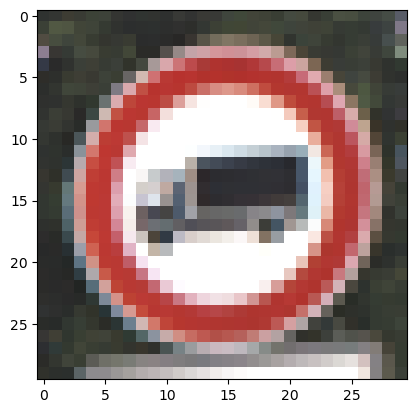

In [4]:
imgPath = os.path.join(trainP,"16\\00016_00001_00026.png")
im = Image.open(imgPath)
im = im.resize((30,30))
#im = np.array(im)
plt.imshow(im)
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

Xtrain,Xtest,ytrain,ytest = train_test_split(data,labels,test_size=0.2,random_state=1)
print(Xtrain.shape)
print(Xtest.shape)

(31367, 30, 30, 3)
(7842, 30, 30, 3)


In [6]:
ytrain = to_categorical(ytrain,classes)
ytest = to_categorical(ytest,classes)
print(ytrain.shape)
print(ytest.shape)

(31367, 43)
(7842, 43)


In [7]:
Xtrain = Xtrain/255
Xtest = Xtest/255

In [8]:
model = Sequential()
model.add(Conv2D(32,(5,5),activation="relu",input_shape=Xtrain.shape[1:]))
model.add(Conv2D(32,(5,5),activation="relu"))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))
model.add(Conv2D(64,(3,3),activation="relu"))
model.add(Conv2D(64,(3,3),activation="relu"))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(256,"relu"))
model.add(Dropout(0.5))
model.add(Dense(classes,"softmax"))

In [9]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])
fittedModel = model.fit(Xtrain,ytrain,epochs=10,batch_size=64,validation_data=(Xtest,ytest))

Epoch 1/10
491/491 [==============================] - 28s 55ms/step - loss: 1.5676 - accuracy: 0.5614 - val_loss: 0.2776 - val_accuracy: 0.9251
Epoch 2/10
491/491 [==============================] - 26s 52ms/step - loss: 0.3211 - accuracy: 0.9016 - val_loss: 0.0761 - val_accuracy: 0.9806
Epoch 3/10
491/491 [==============================] - 25s 51ms/step - loss: 0.1897 - accuracy: 0.9433 - val_loss: 0.0478 - val_accuracy: 0.9869
Epoch 4/10
491/491 [==============================] - 26s 54ms/step - loss: 0.1451 - accuracy: 0.9565 - val_loss: 0.0335 - val_accuracy: 0.9901
Epoch 5/10
491/491 [==============================] - 24s 49ms/step - loss: 0.1143 - accuracy: 0.9656 - val_loss: 0.0260 - val_accuracy: 0.9930
Epoch 6/10
491/491 [==============================] - 24s 49ms/step - loss: 0.0944 - accuracy: 0.9718 - val_loss: 0.0202 - val_accuracy: 0.9946
Epoch 7/10
491/491 [==============================] - 25s 51ms/step - loss: 0.0798 - accuracy: 0.9755 - val_loss: 0.0242 - val_accuracy:

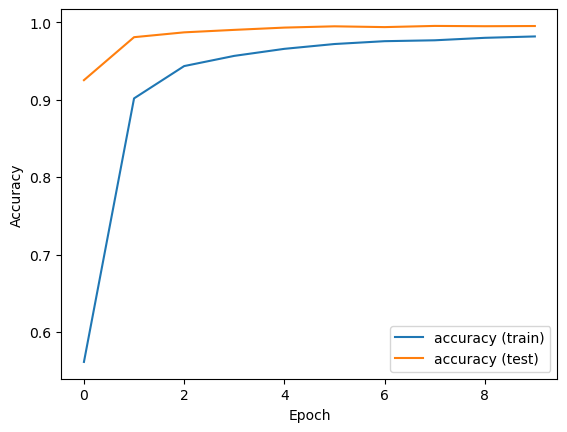

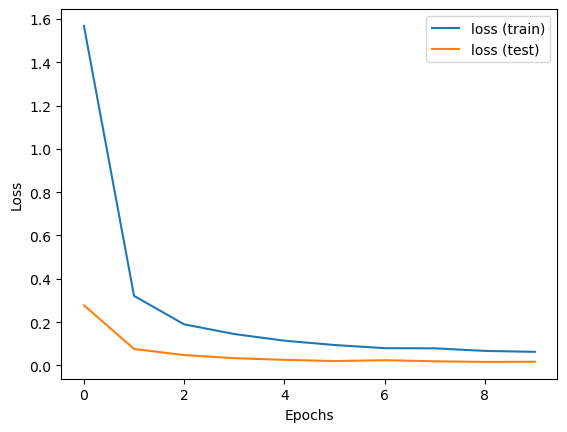

In [10]:
plt.plot(fittedModel.history["accuracy"],label="accuracy (train)")
plt.plot(fittedModel.history["val_accuracy"],label="accuracy (test)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(fittedModel.history["loss"],label="loss (train)")
plt.plot(fittedModel.history["val_loss"],label="loss (test)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [11]:
testP = os.path.join(path,"Test")
testDF = pd.read_csv(os.path.join(path,"Test.csv"))
testLabels = testDF["ClassId"]
print(testLabels)
testData = []
for image in os.listdir(testP):
    img = Image.open(os.path.join(testP,image))
    img = img.resize((30,30))
    img = np.array(img)
    testData.append(img)

testData = np.array(testData)
testData = testData/255
testLabels = np.array(testLabels)
testLabels = to_categorical(testLabels,classes)


0        16
1         1
2        38
3        33
4        11
         ..
12625    12
12626    33
12627     6
12628     7
12629    10
Name: ClassId, Length: 12630, dtype: int64


In [12]:
loss, accuracy = model.evaluate(testData,testLabels)
print(accuracy)

395/395 [==============================] - 3s 6ms/step - loss: 0.1560 - accuracy: 0.9645
0.9645289182662964


In [13]:
model.save("trafficsignmodel.h5")